# Robust RIS-Assisted Federated Learning under Adversarial Attacks
This notebook implements a complete simulation framework for Reconfigurable Intelligent Surface (RIS) assisted Federated Learning. It features a numerically stable **Gibbs Sampling** algorithm for joint device selection and beamforming, evaluated against **FGSM Data Poisoning** and **Model Poisoning** attacks.

## Cell 1 — Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import json
import os
import copy
import warnings
from typing import Tuple, List, Dict, Optional
from dataclasses import dataclass, field
from tqdm import tqdm

# TorchAttacks — optional; falls back to built-in FGSM/PGD
try:
    from torchattacks import FGSM, PGD
    TORCHATTACKS_AVAILABLE = True
except ImportError:
    TORCHATTACKS_AVAILABLE = False
    print("⚠️  TorchAttacks not installed — using built-in fallback implementations")

warnings.filterwarnings('ignore')
print("✅ Imports complete")

✅ Imports complete


In [2]:
import random

def set_seed(seed: int) -> None:
    """Fix random seeds across all libraries for fully reproducible trials.

    Calling set_seed(42 + t) before constructing RISFLSystem guarantees that
    Trial t always starts from identical network topology, wireless channel
    realisations, and data splits — regardless of the malicious-client count
    being evaluated.  This enables fair paired comparisons across conditions.

    Parameters
    ----------
    seed : int
        Master seed value.  Pass ``42 + t`` for trial index ``t``.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


print("✅ set_seed() defined — reproducible trials enabled")

✅ set_seed() defined — reproducible trials enabled


## 1. System Configuration & Setup

## Cell 2 — Config (Single Source of Truth)

In [3]:
@dataclass
class Config:
    """
    SINGLE SOURCE OF TRUTH for the entire pipeline.

    All modules receive this object and read from it directly.
    No parameter is ever re-defined or overridden elsewhere.
    """

    # ── Client / FL settings ──────────────────────────────────────────────
    num_clients: int = 10            # Total IoT devices (small-scale sim)

    # ── Local training ────────────────────────────────────────────────────
    local_epochs: int = 5            # Epochs per client per FL round
    batch_size: int = 64
    lr: float = 0.01
    lr_min: float = 1e-4
    lr_decay_per_round: float = 0.998
    weight_decay: float = 5e-4
    max_grad_norm: float = 10.0

    # ── Wireless channel ──────────────────────────────────────────────────
    num_bs_antennas: int = 5         # BS antennas (N)
    num_ris_elements: int = 40       # RIS reflecting elements (L)
    sigma_n: float = 1e-13           # Thermal noise power (W) ≈ −100 dBm
    P0: float = 0.01                 # Tx power (W) = 10 dBm
    noiseless: bool = False          # True → bypass wireless noise
    device_range: float = 50.0       # Max x-range for cluster-1 devices (m)
    alpha_direct: float = 3.5        # Path-loss exponent (direct link)
    ris_position: tuple = (50.0, 0.0, 10.0)   # RIS (x, y, z) metres
    bs_position:  tuple = (0.0,  0.0, 25.0)   # BS  (x, y, z) metres

    # ── Gibbs sampler ─────────────────────────────────────────────────────
    gibbs_max_iter: int = 50
    gibbs_beta_init: float = 10.0
    gibbs_beta_decay: float = 0.98
    gibbs_beta_min: float = 0.1
    gibbs_lambda_sel: float = 0.5    # Balanced — dynamic normalisation on
    gibbs_lambda_comm: float = 0.5
    gibbs_reopt_interval: int = 1    # Re-run Gibbs every N FL rounds

    # ── Training phases ───────────────────────────────────────────────────
    phase1_rounds: int = 200
    phase2_rounds: int = 200

    # ── Attack settings ───────────────────────────────────────────────────
    #   attack_type controls DATA POISONING (FGSM / PGD / none)
    #   malicious_upscale controls MODEL-UPDATE POISONING (scale Δw)
    #   Both are independent and can be combined or used alone.
    attack_type: str = 'fgsm'        # 'fgsm' | 'pgd' | 'none'
    attack_epsilon: float = 8.0 / 255
    attack_alpha: float = 2.0 / 255  # PGD step size
    attack_steps: int = 10           # PGD iterations
    malicious_upscale: float = 5.0   # Scale factor applied to Δw of malicious clients
                                     # Set to 1.0 to disable model-update poisoning

    # ── Early stopping ────────────────────────────────────────────────────
    early_stopping: bool = True
    patience: int = 50
    min_delta: float = 1e-5

    # ── System ────────────────────────────────────────────────────────────
    device: str = field(
        default_factory=lambda: 'cuda:1' if torch.cuda.is_available() else 'cpu'
    )
    log_file: str = 'results/simulation_logs.txt'   # File logger output path

    def summary(self):
        """Print a compact parameter summary to terminal."""
        print("\n" + "═" * 64)
        print("  RIS-FL Config  (v2)")
        print("═" * 64)
        print(f"  Clients M={self.num_clients} | BS N={self.num_bs_antennas} | RIS L={self.num_ris_elements}")
        print(f"  σ²_n={self.sigma_n:.2e} W | P0={self.P0:.2e} W ({10*np.log10(self.P0*1000):.0f} dBm)")
        print(f"  Gibbs: β₀={self.gibbs_beta_init}, decay={self.gibbs_beta_decay}, β_min={self.gibbs_beta_min}")
        print(f"  λ_sel={self.gibbs_lambda_sel}, λ_comm={self.gibbs_lambda_comm}  (dynamic z-score norm ON)")
        print(f"  Phases: P1={self.phase1_rounds}r  P2={self.phase2_rounds}r")
        print(f"  Data poisoning : {self.attack_type.upper()}  ε={self.attack_epsilon*255:.1f}/255")
        print(f"  Model poisoning: upscale={self.malicious_upscale}×  (set to 1.0 to disable)")
        print(f"  Device: {self.device} | Log → {self.log_file}")
        print("═" * 64 + "\n")


def clear_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


print("✅ Config defined")

✅ Config defined


## Cell 3 — SimulationLogger  *(Req 6)*

In [4]:
class SimulationLogger:
    """
    Writes all verbose simulation events to a text file.

    The terminal is kept clean: only tqdm bars and final summaries
    are printed there.  Everything else goes to `log_file`.

    Usage
    -----
    logger = SimulationLogger('results/simulation_logs.txt')
    logger.init_trial(trial_id, client_coords)
    logger.log_round(trial_id, round_idx, active_ids, malicious_ids)
    """

    def __init__(self, log_path: str):
        self.log_path = log_path
        os.makedirs(os.path.dirname(log_path), exist_ok=True)
        # Clear / create file at experiment start
        with open(log_path, 'w', encoding='utf-8') as f:
            f.write("=" * 70 + "\n")
            f.write("  RIS-FL Simulation Log\n")
            f.write("=" * 70 + "\n\n")

    def _write(self, line: str):
        """Append a single line to the log file."""
        with open(self.log_path, 'a', encoding='utf-8') as f:
            f.write(line + "\n")

    def init_trial(
        self,
        trial_id: int,
        client_coords: np.ndarray,   # shape (M, 3) — (x, y, z) per client
        n_malicious: int,
        attack_type: str,
    ):
        """
        Write trial header + client topology table to log file.
        Nothing is printed to the terminal.
        """
        self._write("")
        self._write("─" * 70)
        self._write(f"  TRIAL {trial_id:02d}   malicious={n_malicious}   attack={attack_type.upper()}")
        self._write("─" * 70)
        self._write(f"  {'Client ID':>9} | {'x (m)':>8} | {'y (m)':>8} | {'z (m)':>8}")
        self._write(f"  {'-'*9}-+-{'-'*8}-+-{'-'*8}-+-{'-'*8}")
        for cid, (cx, cy, cz) in enumerate(client_coords):
            self._write(f"  Client {cid:>3d}  | {cx:>8.2f} | {cy:>8.2f} | {cz:>8.2f}")
        self._write("")

    def log_round(
        self,
        trial_id: int,
        round_idx: int,
        active_ids: List[int],
        malicious_ids: List[int],
        acc: float,     # Thêm tham số acc
        loss: float,    # Thêm tham số loss
    ):
        """
        Append one line per FL round to the log file.
        Format: Trial T | Round R | Acc: XX.XX% | Loss: X.XXX | Active [...] | Mal [...]
        """
        mal_str = str(sorted(malicious_ids)) if malicious_ids else '[]'
        self._write(
            f"  T{trial_id:02d} | R{round_idx+1:04d} "
            f"| Acc: {acc*100:5.2f}% | Loss: {loss:5.3f} "
            f"| Active {sorted(active_ids)} "
            f"| Mal {mal_str}"
        )

    def log_trial_summary(self, trial_id: int, p1_acc: float, p2_acc: float, drop: float):
        """Write per-trial accuracy summary."""
        self._write("")
        self._write(
            f"  Trial {trial_id:02d} summary: "
            f"P1={p1_acc*100:.2f}%  P2={p2_acc*100:.2f}%  drop={drop:.2f}%"
        )


print("✅ SimulationLogger defined")

✅ SimulationLogger defined


## Cell 4 — Model & Parameter Helpers  *(Req 4: optimised `set_params`)*

In [5]:
class CIFAR10Model(nn.Module):
    """CNN with BatchNorm for CIFAR-10 classification."""

    def __init__(self, dropout_rate: float = 0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 5, padding=2)
        self.bn1   = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, 5, padding=2)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 8 * 8, 384)
        self.bn3   = nn.BatchNorm1d(384)
        self.fc2   = nn.Linear(384, 192)
        self.bn4   = nn.BatchNorm1d(192)
        self.fc3   = nn.Linear(192, 10)
        self.drop  = nn.Dropout(dropout_rate)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 64 * 8 * 8)
        x = self.drop(torch.relu(self.bn3(self.fc1(x))))
        x = self.drop(torch.relu(self.bn4(self.fc2(x))))
        return self.fc3(x)


# ── Flat parameter utilities ──────────────────────────────────────────────────

def get_flat_params(model: nn.Module) -> np.ndarray:
    """Extract trainable parameters as a 1-D float32 numpy array."""
    return np.concatenate(
        [p.data.cpu().numpy().ravel() for p in model.parameters()]
    ).astype(np.float32)


def set_flat_params(model: nn.Module, flat: np.ndarray, device: str):
    """
    Restore trainable parameters from a 1-D numpy array.

    Req 4 optimisation: convert the *entire* array to a single GPU tensor
    first, then slice it per parameter — avoids one `torch.tensor()` call
    per parameter in the original implementation.
    """
    flat_t = torch.as_tensor(flat, dtype=torch.float32, device=device)
    idx = 0
    for param in model.parameters():
        n = param.numel()
        param.data.copy_(flat_t[idx : idx + n].reshape(param.shape))
        idx += n


# ── BatchNorm running-stat helpers ────────────────────────────────────────────

def get_bn_stats(model: nn.Module) -> Dict:
    stats: Dict = {}
    for name, mod in model.named_modules():
        if isinstance(mod, (nn.BatchNorm2d, nn.BatchNorm1d)):
            stats[name] = {
                'mean': mod.running_mean.cpu().numpy().astype(np.float32),
                'var':  mod.running_var.cpu().numpy().astype(np.float32),
                'n':    int(mod.num_batches_tracked.item()),
            }
    return stats


def set_bn_stats(model: nn.Module, stats: Dict, device: str):
    for name, mod in model.named_modules():
        if isinstance(mod, (nn.BatchNorm2d, nn.BatchNorm1d)) and name in stats:
            s = stats[name]
            mod.running_mean.copy_(torch.tensor(s['mean'], device=device, dtype=torch.float32))
            mod.running_var.copy_(torch.tensor(s['var'],   device=device, dtype=torch.float32))
            mod.num_batches_tracked.copy_(torch.tensor(s['n'], device=device))


def aggregate_bn_stats(stats_list: List[Dict]) -> Dict:
    """Simple mean aggregation of BatchNorm running stats across active clients."""
    if not stats_list:
        return {}
    agg: Dict = {}
    for layer in stats_list[0]:
        agg[layer] = {
            'mean': np.mean([s[layer]['mean'] for s in stats_list], axis=0).astype(np.float32),
            'var':  np.mean([s[layer]['var']  for s in stats_list], axis=0).astype(np.float32),
            'n':    stats_list[0][layer]['n'],
        }
    return agg


print("✅ Model & parameter helpers defined")

✅ Model & parameter helpers defined


## Cell 5 — Data Loading

In [6]:
def load_data(cfg: Config) -> Tuple[List[DataLoader], DataLoader]:
    """Download CIFAR-10, IID-split uniformly across clients (no augmentation)."""
    tfm = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.491, 0.482, 0.447], [0.247, 0.243, 0.262]),
    ])
    trainset = torchvision.datasets.CIFAR10(root='./Data', train=True,  download=True, transform=tfm)
    testset  = torchvision.datasets.CIFAR10(root='./Data', train=False, download=True, transform=tfm)

    per_client = len(trainset) // cfg.num_clients
    lengths    = [per_client] * cfg.num_clients
    lengths[0] += len(trainset) - sum(lengths)   # absorb remainder into client 0
    splits = random_split(trainset, lengths)

    train_loaders = [
        DataLoader(s, batch_size=cfg.batch_size, shuffle=True, num_workers=2)
        for s in splits
    ]
    test_loader = DataLoader(testset, batch_size=cfg.batch_size * 2, shuffle=False, num_workers=2)

    print(f"  Data: {cfg.num_clients} clients × ~{per_client} samples each")
    return train_loaders, test_loader


print("✅ Data loader defined")

✅ Data loader defined


## Cell 6 — Channel Generation  *(Req 5: returns client coordinates)*

In [7]:
def generate_channels(cfg: Config) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate i.i.d. Rayleigh fading channels for a fresh trial.

    Returns
    -------
    h_direct    : complex64  shape (N, M)    — direct BS-device channel
    G_ris       : complex64  shape (N, L, M) — cascaded RIS channel
    client_xyz  : float32    shape (M, 3)    — (x, y, z) coords of every
                                               device (z = 0 for ground devices)
    """
    fc     = 915e6
    g_bs   = 10 ** (5.0 / 10)    # BS gain
    g_ris  = 10 ** (5.0 / 10)    # RIS gain
    g_ue   = 1.0                  # UE gain (0 dB)
    d_elem = 0.1                  # RIS element spacing

    N, L, M = cfg.num_bs_antennas, cfg.num_ris_elements, cfg.num_clients
    ris_pos = np.array(cfg.ris_position)
    bs_pos  = np.array(cfg.bs_position)

    # Two-cluster device layout
    n1 = M // 2;  n2 = M - n1
    dx = np.concatenate([
        np.random.rand(n1) * cfg.device_range - cfg.device_range,   # cluster 1
        np.random.rand(n2) * cfg.device_range + 100,                 # cluster 2
    ]).astype(np.float32)
    dy = (np.random.rand(M) * 20 - 10).astype(np.float32)
    dz = np.zeros(M, dtype=np.float32)   # all devices at ground level z = 0

    # Collect coordinates — shape (M, 3)
    client_xyz = np.stack([dx, dy, dz], axis=1)   # float32, (M, 3)

    # Distance calculations
    d_ue_ris = np.sqrt((dx - ris_pos[0])**2 + (dy - ris_pos[1])**2 + ris_pos[2]**2)
    d_ris_bs = float(np.linalg.norm(bs_pos - ris_pos))
    d_ue_bs  = np.sqrt((dx - bs_pos[0])**2  + (dy - bs_pos[1])**2  + bs_pos[2]**2)

    lam = 3e8 / fc
    pl_direct = (g_bs * g_ue * (lam / (4 * np.pi * d_ue_bs)) ** cfg.alpha_direct).astype(np.float32)
    pl_ris    = (
        g_bs * g_ue * g_ris * L**2 * d_elem**2 / (4 * np.pi)
        * (lam / (4 * np.pi * d_ue_ris))**2
        * (lam / (4 * np.pi * d_ris_bs))**2
    ).astype(np.float32)

    def _rayleigh(rows, cols):
        return ((np.random.randn(rows, cols) + 1j * np.random.randn(rows, cols)) / np.sqrt(2))

    h_direct = (_rayleigh(N, M) @ np.diag(np.sqrt(pl_direct))).astype(np.complex64)
    H_rb     = _rayleigh(N, L).astype(np.complex64)
    h_ur     = (_rayleigh(L, M) @ np.diag(np.sqrt(pl_ris))).astype(np.complex64)
    G_ris    = np.stack(
        [H_rb @ np.diag(h_ur[:, m]) for m in range(M)], axis=2
    ).astype(np.complex64)

    return h_direct, G_ris, client_xyz


print("✅ Channel generation defined (returns client_xyz)")

✅ Channel generation defined (returns client_xyz)


## 2. Advanced Gibbs Sampling Algorithm

## Cell 7 — GibbsSampler (unchanged from v1)

**Objective Function (Numerically Stabilized):**
The sampler minimizes the joint objective of data exclusion penalty and wireless communication MSE, mapped to dynamically calibrated Z-scores to prevent numerical overflow:

$$\text{Obj}(x, \theta, f) = \lambda_{\text{sel}} \cdot \frac{d_{\text{sel}}(x) - \mu_s}{\sigma_s} + \lambda_{\text{comm}} \cdot \frac{d_{\text{comm}}(x, \theta, f) - \mu_c}{\sigma_c}$$

*To prevent overflow in transition probabilities, we apply the Log-Sum-Exp trick.*

In [8]:
class GibbsSampler:
    """
    Numerically-stable Gibbs sampler for joint device-selection /
    RIS-beamforming optimisation.

    Stabilisation techniques (unchanged from v1):
      - Warm-up z-score calibration replaces the 1e-15 magic constant.
      - Log-Sum-Exp softmax avoids exp overflow/underflow.
      - NaN/Inf guard ensures np.random.choice always receives a valid pmf.
    """

    N_WARMUP = 8

    def __init__(self, cfg: Config, K_m: np.ndarray,
                 h_direct: np.ndarray, G_ris: np.ndarray):
        self.cfg      = cfg
        self.K_m      = K_m.astype(np.float64)
        self.h_direct = h_direct.astype(np.complex128)
        self.G_ris    = G_ris.astype(np.complex128)
        self.M        = cfg.num_clients
        self.N        = cfg.num_bs_antennas
        self.L        = cfg.num_ris_elements
        self.K_total  = float(np.sum(K_m))
        self._dsel_stats:  Optional[Tuple[float, float]] = None
        self._dcomm_stats: Optional[Tuple[float, float]] = None
        self.best_x     = np.ones(self.M, dtype=np.int32)
        self.best_f:     Optional[np.ndarray] = None
        self.best_theta: Optional[np.ndarray] = None

    def _raw_components(self, x, f, theta):
        active_mask = x.astype(bool)
        inactive_pen = np.sum(((1 - x) * self.K_m) ** 2)
        d_sel = (4.0 / self.K_total**2) * inactive_pen
        active_idx = np.where(active_mask)[0]
        if len(active_idx) == 0:
            return d_sel, 1e30
        K_active_sum = float(np.sum(x * self.K_m))
        max_ratio = 0.0
        for m in active_idx:
            h_eff = self.h_direct[:, m] + self.G_ris[:, :, m] @ theta
            g     = max(float(np.abs(np.vdot(f, h_eff))**2), 1e-25)
            max_ratio = max(max_ratio, float(self.K_m[m]**2) / g)
        d_comm = (self.cfg.sigma_n / self.cfg.P0) * K_active_sum**2 * max_ratio
        return d_sel, d_comm

    def _calibrate(self, samples):
        dsels  = [s[0] for s in samples]
        dcomms = [s[1] for s in samples]
        self._dsel_stats  = (float(np.mean(dsels)),  max(float(np.std(dsels)),  1e-30))
        self._dcomm_stats = (float(np.mean(dcomms)), max(float(np.std(dcomms)), 1e-30))

    def _objective(self, x, f, theta):
        d_sel, d_comm = self._raw_components(x, f, theta)
        if self._dsel_stats is None:
            return float(d_sel + d_comm)
        mu_s, sig_s   = self._dsel_stats
        mu_c, sig_c   = self._dcomm_stats
        z_sel  = (d_sel  - mu_s) / sig_s
        z_comm = (d_comm - mu_c) / sig_c
        return self.cfg.gibbs_lambda_sel * z_sel + self.cfg.gibbs_lambda_comm * z_comm

    def _init_f_theta(self, active_mask):
        idx = np.where(active_mask)[0]
        if len(idx) == 0:
            f     = (np.random.randn(self.N) + 1j*np.random.randn(self.N)) / np.sqrt(self.N)
            theta = np.exp(1j * 2 * np.pi * np.random.rand(self.L))
            return f.astype(np.complex128), theta.astype(np.complex128)
        f_sum = sum(float(self.K_m[m]) * self.h_direct[:, m].conj() for m in idx)
        nm    = np.linalg.norm(f_sum)
        f     = (f_sum / nm) if nm > 1e-15 else \
                ((np.random.randn(self.N) + 1j*np.random.randn(self.N)) / np.sqrt(self.N))
        G_avg = self.G_ris[:, :, idx].mean(axis=2)
        theta = np.exp(-1j * np.angle(G_avg.T.conj() @ f + 1e-15))
        return f.astype(np.complex128), theta.astype(np.complex128)

    def _opt_f_theta(self, x, n_iter=15):
        active_mask = x.astype(bool)
        idx         = np.where(active_mask)[0]
        f, theta    = self._init_f_theta(active_mask)
        if len(idx) == 0:
            return f, theta
        prev_raw = sum(self._raw_components(x, f, theta))
        for _ in range(n_iter):
            num_f = sum(
                float(self.K_m[m]**2) * (self.h_direct[:, m] + self.G_ris[:, :, m] @ theta).conj()
                for m in idx
            )
            nm = np.linalg.norm(num_f)
            if nm < 1e-15:
                break
            f = num_f / nm
            num_th = sum(
                float(self.K_m[m]**2) * (self.G_ris[:, :, m].T.conj() @ f)
                * np.conj(np.vdot(f, self.h_direct[:, m]))
                for m in idx
            )
            theta    = np.exp(1j * np.angle(num_th + 1e-15))
            curr_raw = sum(self._raw_components(x, f, theta))
            if abs(curr_raw - prev_raw) / (abs(prev_raw) + 1e-10) < 1e-6:
                break
            prev_raw = curr_raw
        return f, theta

    @staticmethod
    def _logsumexp_probs(scores, beta):
        a     = -scores / max(beta, 1e-30)
        exp_a = np.exp(a - np.max(a))
        probs = np.clip(exp_a, 0.0, None)
        total = probs.sum()
        if total < 1e-30 or not np.isfinite(total):
            return np.ones(len(scores)) / len(scores)
        return probs / total

    def optimize(self, verbose=False):
        cfg  = self.cfg
        beta = cfg.gibbs_beta_init

        # Warm-up calibration
        warmup_xs = [np.ones(self.M, dtype=np.int32)]
        for i in range(min(self.N_WARMUP - 1, self.M)):
            xt = np.ones(self.M, dtype=np.int32);  xt[i] = 0
            warmup_xs.append(xt)
        self._calibrate(
            [self._raw_components(xw, *self._opt_f_theta(xw, 5)) for xw in warmup_xs]
        )

        x = np.ones(self.M, dtype=np.int32)
        f, theta = self._opt_f_theta(x)
        best_obj = self._objective(x, f, theta)
        best_x, best_f, best_theta = x.copy(), f.copy(), theta.copy()

        itr = range(cfg.gibbs_max_iter) if verbose else \
              tqdm(range(cfg.gibbs_max_iter), desc="  Gibbs", leave=False)

        for j in itr:
            candidates = [x.copy()]
            for m in range(self.M):
                xc = x.copy();  xc[m] ^= 1
                if np.sum(xc) > 0:
                    candidates.append(xc)

            objs, fs, ths = [], [], []
            for xc in candidates:
                fc, tc = self._opt_f_theta(xc)
                objs.append(self._objective(xc, fc, tc))
                fs.append(fc);  ths.append(tc)

            objs_arr = np.array(objs, dtype=np.float64)
            probs    = self._logsumexp_probs(objs_arr, beta)
            try:
                idx_c = np.random.choice(len(candidates), p=probs)
            except ValueError:
                idx_c = int(np.argmin(objs_arr))

            x, f, theta = candidates[idx_c], fs[idx_c], ths[idx_c]
            if objs_arr[idx_c] < best_obj:
                best_obj = objs_arr[idx_c]
                best_x, best_f, best_theta = x.copy(), f.copy(), theta.copy()

            beta = max(beta * cfg.gibbs_beta_decay, cfg.gibbs_beta_min)
            if verbose:
                print(f"    [Gibbs {j+1:2d}] β={beta:.4f} active={int(np.sum(x))} obj={objs_arr[idx_c]:.4f}")

        self.best_x, self.best_f, self.best_theta = best_x, best_f, best_theta
        return best_x, best_f, best_theta


print("✅ GibbsSampler defined")

✅ GibbsSampler defined


## Cell 8 — Wireless Aggregation  *(Req 2: operates on Δw, not raw weights)*

In [9]:
def wireless_aggregation(
    cfg: Config,
    deltas: np.ndarray,         # (n_active, n_params)  — model UPDATES Δw
    K_m: np.ndarray,            # (num_clients,)         — dataset sizes
    active_mask: np.ndarray,    # (num_clients,) bool
    f: np.ndarray,
    theta: np.ndarray,
    h_direct: np.ndarray,
    G_ris: np.ndarray,
) -> np.ndarray:
    """
    Weighted-average aggregation of model UPDATES (Δw) with wireless noise.

    Req 2 fix: η (power scaling) is now computed from `var(Δw)` — the
    variance of parameter *updates*, which is the physically meaningful
    quantity that determines the transmitted signal power.

    The caller is responsible for adding the returned mean_delta back to
    the global model weights.
    """
    active_K     = K_m[active_mask]
    weighted_sum = (deltas.T * active_K).sum(axis=1)   # Σ K_m · Δw_m

    if cfg.noiseless:
        return weighted_sum / active_K.sum()

    # Compute optimal η per active device (using Δw variance — Req 2)
    active_idx = np.where(active_mask)[0]
    etas = []
    for i, m in enumerate(active_idx):
        h_eff = h_direct[:, m] + G_ris[:, :, m] @ theta
        g     = max(float(np.abs(np.vdot(f, h_eff))**2), 1e-25)
        # var(Δw) is the signal energy; use this for meaningful η
        delta_var = max(float(np.var(deltas[i])), 1e-20)
        etas.append(cfg.P0 * g / (K_m[m]**2 * delta_var))

    eta   = min(etas) if etas else 1.0
    K_sum = float(active_K.sum())

    # Aggregate mean delta with channel noise
    mean_delta   = weighted_sum / K_sum
    noise        = np.random.randn(len(mean_delta)).astype(np.float32) * np.sqrt(cfg.sigma_n)
    scaled_noise = noise / (max(np.sqrt(eta), 1e-15) * K_sum)

    return np.clip(mean_delta + scaled_noise, -10.0, 10.0)   # clip delta, not weights


print("✅ Wireless aggregation (Δw) defined")

✅ Wireless aggregation (Δw) defined


## Cell 9 — AttackWrapper  *(Req 3: data poisoning only)*

In [10]:
class AttackWrapper:
    """
    DATA POISONING wrapper (FGSM / PGD / none).

    Req 3 clarification: This class is ONLY responsible for corrupting
    input batches before local training (data poisoning).  Model-update
    scaling (model poisoning) is handled separately in `train_round` by
    multiplying Δw by `cfg.malicious_upscale`.  The two strategies are
    fully decoupled and independently controllable.
    """

    def __init__(self, cfg: Config, model: nn.Module):
        self.atype   = cfg.attack_type.lower()
        self.device  = cfg.device
        self._attack = None

        if self.atype == 'none':
            return

        if TORCHATTACKS_AVAILABLE:
            if self.atype == 'fgsm':
                self._attack = FGSM(model, eps=cfg.attack_epsilon)
            elif self.atype == 'pgd':
                self._attack = PGD(model, eps=cfg.attack_epsilon,
                                   alpha=cfg.attack_alpha, steps=cfg.attack_steps)
        else:
            self._cfg   = cfg
            self._model = model

    def _fgsm_manual(self, x, y):
        eps = self._cfg.attack_epsilon
        xr  = x.clone().detach().requires_grad_(True)
        nn.CrossEntropyLoss()(self._model(xr), y).backward()
        return torch.clamp(xr + eps * xr.grad.sign(), 0, 1).detach()

    def _pgd_manual(self, x, y):
        eps, alpha = self._cfg.attack_epsilon, self._cfg.attack_alpha
        x_adv = x.clone().detach() + 0.001 * torch.randn_like(x)
        for _ in range(self._cfg.attack_steps):
            x_adv = x_adv.detach().requires_grad_(True)
            nn.CrossEntropyLoss()(self._model(x_adv), y).backward()
            with torch.no_grad():
                x_adv = torch.clamp(x_adv + alpha * x_adv.grad.sign(), x - eps, x + eps)
                x_adv = torch.clamp(x_adv, 0, 1)
        return x_adv.detach()

    def apply(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """Return adversarially perturbed inputs (data poisoning only)."""
        if self.atype == 'none':
            return x
        if TORCHATTACKS_AVAILABLE and self._attack is not None:
            self._attack.model.eval()
            adv = self._attack(x, y)
            self._attack.model.train()
            return adv
        if hasattr(self, '_model'):
            self._model.eval()
            adv = self._fgsm_manual(x, y) if self.atype == 'fgsm' else self._pgd_manual(x, y)
            self._model.train()
            return adv
        return x


print("✅ AttackWrapper (data poisoning only) defined")

✅ AttackWrapper (data poisoning only) defined


## 3. Federated Learning System Architecture

## Cell 10 — RISFLSystem  *(Req 1, 2, 4, 5 integrated)*

In [11]:
class RISFLSystem:
    """
    End-to-end RIS-assisted Federated Learning system (v2).

    Key v2 changes
    --------------
    Req 1  Early-stopping state is deep-copied to CPU (.cpu().clone()),
           preventing silent overwrite when `set_flat_params` mutates tensors.
    Req 2  `_local_train` returns Δw = local_w − global_w instead of raw
           weights.  `train_round` computes agg_delta via wireless_aggregation,
           then applies global_w ← global_w + agg_delta.
    Req 4  A single `self.worker_model` is instantiated once in __init__ and
           reused by every local-training call (no VRAM fragmentation).
    Req 5  Client (x,y,z) coordinates are stored and printed at init time.
           train_round logs active/malicious IDs via SimulationLogger.
    """

    def __init__(self, cfg: Config, logger: Optional['SimulationLogger'] = None):
        self.cfg    = cfg
        self.device = cfg.device
        self.logger = logger

        # ── Models ────────────────────────────────────────────────────────
        self.global_model = CIFAR10Model().to(self.device)
        self.cloud_model  = CIFAR10Model().to(self.device)
        self.cloud_model.load_state_dict(self.global_model.state_dict())

        # Req 4: single reusable worker model — prevents VRAM fragmentation
        self.worker_model = CIFAR10Model().to(self.device)

        # ── Data ──────────────────────────────────────────────────────────
        self.train_loaders, self.test_loader = load_data(cfg)
        self.K_m     = np.array([len(l.dataset) for l in self.train_loaders], dtype=np.float32)
        self.K_total = float(self.K_m.sum())

        # ── Wireless channels (fresh every trial) ─────────────────────────
        self.h_direct, self.G_ris, self.client_xyz = generate_channels(cfg)

        # Req 5: print client topology to terminal
        self._print_topology()

        # ── Gibbs sampler ─────────────────────────────────────────────────
        self.sampler = GibbsSampler(cfg, self.K_m, self.h_direct, self.G_ris)

        # Communication parameters (populated after first Gibbs run)
        self.active_mask: np.ndarray = np.ones(cfg.num_clients, dtype=bool)
        self.f:     Optional[np.ndarray] = None
        self.theta: Optional[np.ndarray] = None

        # ── Attack state ──────────────────────────────────────────────────
        self.num_malicious: int = 0

        # ── Early-stopping state ──────────────────────────────────────────
        self.best_acc:    float = 0.0
        self.best_state:  Optional[Dict] = None   # CPU-cloned tensors (Req 1)
        self.stale_rounds: int = 0

        # ── Metrics ───────────────────────────────────────────────────────
        self.metrics: Dict[str, List] = {
            'test_acc': [], 'train_loss': [], 'num_active': []
        }

        # Trial ID (set externally by run_multiple_trials)
        self.trial_id: int = 0

    # ── Topology display (Req 5) ──────────────────────────────────────────

    def _print_topology(self):
        """Pretty-print client coordinates to terminal on init."""
        M = self.cfg.num_clients
        ris = self.cfg.ris_position
        bs  = self.cfg.bs_position
        print()
        print("  " + "─" * 52)
        print(f"  Network Topology  ({M} clients)")
        print("  " + "─" * 52)
        print(f"  BS  @ x={bs[0]:6.1f}  y={bs[1]:6.1f}  z={bs[2]:6.1f} m")
        print(f"  RIS @ x={ris[0]:6.1f}  y={ris[1]:6.1f}  z={ris[2]:6.1f} m")
        print(f"  {'─'*50}")
        print(f"  {'ID':>4}  {'x (m)':>8}  {'y (m)':>8}  {'z (m)':>8}")
        print(f"  {'─'*4}  {'─'*8}  {'─'*8}  {'─'*8}")
        for cid, (cx, cy, cz) in enumerate(self.client_xyz):
            print(f"  {cid:>4}  {cx:>8.2f}  {cy:>8.2f}  {cz:>8.2f}")
        print("  " + "─" * 52 + "\n")

    # ── Gibbs ─────────────────────────────────────────────────────────────

    def run_gibbs(self, verbose: bool = False):
        x, f, theta = self.sampler.optimize(verbose=verbose)
        self.active_mask = x.astype(bool)
        self.f           = f
        self.theta       = theta

    # ── Local training (Req 2 + Req 4) ───────────────────────────────────

    def _local_train(
        self,
        client_idx: int,
        round_idx: int,
        is_malicious: bool,
    ) -> Tuple[np.ndarray, Dict, float]:
        """
        Train a single client and return
            (delta_w, bn_stats, avg_loss)

        Req 2: Returns Δw = local_w − global_w instead of raw weights.
        Req 4: Reuses `self.worker_model` instead of allocating a new model.
        Req 3: Only applies data poisoning here (AttackWrapper).
               Model-update poisoning (upscale Δw) is done in train_round.
        """
        # Req 4: reuse worker model — just copy current cloud state into it
        self.worker_model.load_state_dict(self.cloud_model.state_dict())

        # Capture global weights BEFORE local update (for computing Δw)
        global_w = get_flat_params(self.cloud_model)

        lr = max(
            self.cfg.lr * (self.cfg.lr_decay_per_round ** round_idx),
            self.cfg.lr_min
        )
        optimizer = optim.SGD(
            self.worker_model.parameters(),
            lr=lr, momentum=0.9, weight_decay=self.cfg.weight_decay
        )
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

        # Req 3: data poisoning — AttackWrapper handles FGSM/PGD on inputs
        attacker = AttackWrapper(self.cfg, self.worker_model) if is_malicious else None

        self.worker_model.train()
        total_loss, n_batches = 0.0, 0

        for _ in range(self.cfg.local_epochs):
            for bx, by in self.train_loaders[client_idx]:
                bx, by = bx.to(self.device), by.to(self.device)
                if attacker is not None:
                    bx = attacker.apply(bx, by)          # data poisoning
                optimizer.zero_grad()
                out  = self.worker_model(bx)
                loss = criterion(out, by)
                if not (torch.isnan(loss) or torch.isinf(loss)):
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(
                        self.worker_model.parameters(), self.cfg.max_grad_norm
                    )
                    optimizer.step()
                    total_loss += loss.item()
                    n_batches  += 1

        local_w  = get_flat_params(self.worker_model)
        bn_stats = get_bn_stats(self.worker_model)

        # Fall back to zero delta if numerical issues arise
        if np.any(~np.isfinite(local_w)):
            delta = np.zeros_like(global_w)
            bn_stats = get_bn_stats(self.cloud_model)
        else:
            # Req 2: return update Δw = local_w − global_w
            delta = np.clip(local_w - global_w, -50.0, 50.0)

        avg_loss = total_loss / max(n_batches, 1)
        return delta, bn_stats, avg_loss

    # ── Evaluation ────────────────────────────────────────────────────────

    def evaluate(self) -> float:
        self.global_model.eval()
        correct = total = 0
        with torch.no_grad():
            for bx, by in self.test_loader:
                bx, by = bx.to(self.device), by.to(self.device)
                preds   = self.global_model(bx).argmax(1)
                correct += preds.eq(by).sum().item()
                total   += by.size(0)
        self.global_model.train()
        return correct / total if total > 0 else 0.0

    # ── One FL round (Req 1, 2, 5) ────────────────────────────────────────

    def train_round(
        self,
        round_idx: int,
        enable_early_stopping: bool = False,
    ) -> Tuple[float, float, bool]:
        """
        Execute one federated round.

        Req 1  best_state is saved with .cpu().clone() to prevent the
               aliasing bug where set_flat_params overwrites the snapshot.
        Req 2  Aggregates Δw then applies: global ← global + agg_delta.
        Req 3  Data poisoning and model poisoning are independent:
               - Data poisoning  → AttackWrapper in _local_train.
               - Model poisoning → Δw ← Δw × malicious_upscale here.
        Req 5  Logs round events (active IDs, malicious IDs) to file logger.
        """
        active_idx = np.where(self.active_mask)[0]
        if len(active_idx) == 0:
            active_idx       = np.arange(self.cfg.num_clients)
            self.active_mask = np.ones(self.cfg.num_clients, dtype=bool)

        # Random malicious selection from active pool
        n_mal = min(self.num_malicious, len(active_idx))
        mal_idx = set(
            np.random.choice(active_idx, size=n_mal, replace=False).tolist()
        ) if n_mal > 0 else set()

        
        

        # ── Local training — collect Δw (Req 2) ───────────────────────────
        # Capture global weights once (used to reconstruct final weights)
        global_w = get_flat_params(self.global_model)

        deltas_list, bn_list, losses = [], [], []

        for m in active_idx:
            is_mal = (m in mal_idx)
            delta, bn, loss = self._local_train(m, round_idx, is_mal)

            # Req 3 — MODEL POISONING: scale Δw (independent of data poisoning)
            if is_mal and self.cfg.malicious_upscale != 1.0:
                delta = delta * self.cfg.malicious_upscale

            deltas_list.append(delta)
            bn_list.append(bn)
            losses.append(loss)

        # ── Wireless aggregation of Δw (Req 2) ────────────────────────────
        agg_delta = wireless_aggregation(
            self.cfg,
            np.array(deltas_list),   # (n_active, n_params) — updates, not weights
            self.K_m,
            self.active_mask,
            self.f, self.theta,
            self.h_direct, self.G_ris,
        )
        agg_bn = aggregate_bn_stats(bn_list)

        # Req 2: apply aggregated delta to global weights
        new_global_w = global_w + agg_delta
        new_global_w = np.clip(new_global_w, -100.0, 100.0)

        set_flat_params(self.global_model, new_global_w, self.device)
        set_flat_params(self.cloud_model,  new_global_w, self.device)
        set_bn_stats(self.global_model, agg_bn, self.device)
        set_bn_stats(self.cloud_model,  agg_bn, self.device)

        # ── Evaluate ──────────────────────────────────────────────────────
        test_acc = self.evaluate()
        avg_loss = float(np.mean(losses))

        self.metrics['test_acc'].append(test_acc)
        self.metrics['train_loss'].append(avg_loss)
        self.metrics['num_active'].append(len(active_idx))

        if self.logger is not None:
            self.logger.log_round(
                self.trial_id,
                round_idx,
                active_idx.tolist(),
                list(mal_idx),
                test_acc,
                avg_loss
            )

        # ── Early stopping (Req 1: CPU deep-copy) ─────────────────────────
        should_stop = False
        if enable_early_stopping and self.cfg.early_stopping:
            if test_acc - self.best_acc > self.cfg.min_delta:
                self.best_acc = test_acc
                # Req 1 FIX: deep-copy tensors to CPU to prevent aliasing
                self.best_state = {
                    'global': {k: v.cpu().clone()
                               for k, v in self.global_model.state_dict().items()},
                    'cloud':  {k: v.cpu().clone()
                               for k, v in self.cloud_model.state_dict().items()},
                }
                self.stale_rounds = 0
            else:
                self.stale_rounds += 1
                if self.stale_rounds >= self.cfg.patience:
                    should_stop = True
                    if self.best_state is not None:
                        self.global_model.load_state_dict(self.best_state['global'])
                        self.cloud_model.load_state_dict(self.best_state['cloud'])

        return test_acc, avg_loss, should_stop


print("✅ RISFLSystem (v2) defined")

✅ RISFLSystem (v2) defined


## Cell 11 — Phase Runners

In [12]:
def run_phase1(system: RISFLSystem, verbose: bool = False) -> float:
    """Phase 1: clean training. Returns final test accuracy."""
    cfg = system.cfg
    system.num_malicious = 0

    print("  Phase 1 — initial Gibbs optimisation …")
    system.run_gibbs(verbose=verbose)

    pbar = tqdm(range(cfg.phase1_rounds), desc="  Phase 1", unit="round", leave=False)
    for r in pbar:
        acc, loss, stop = system.train_round(r, enable_early_stopping=True)

        if (r + 1) % cfg.gibbs_reopt_interval == 0:
            system.run_gibbs(verbose=verbose)

        pbar.set_postfix({'acc': f'{acc*100:.2f}%', 'loss': f'{loss:.3f}',
                          'active': system.metrics['num_active'][-1]})
        if stop:
            print(f"    Early stop at round {r+1}")
            break

    return system.metrics['test_acc'][-1]


def run_phase2(
    system: RISFLSystem,
    phase1_snapshot: Dict,
    num_malicious: int,
    verbose: bool = False,
) -> Tuple[float, List[float]]:
    """
    Phase 2: attack phase.

    Restores from `phase1_snapshot`, runs `cfg.phase2_rounds` rounds
    with `num_malicious` adversarial clients.

    Returns
    -------
    final_acc    : float   — accuracy at the last round
    acc_history  : list    — per-round accuracy for all phase2_rounds
    """
    cfg = system.cfg

    # Restore Phase 1 state
    system.global_model.load_state_dict(phase1_snapshot['global'])
    system.cloud_model.load_state_dict(phase1_snapshot['cloud'])
    system.active_mask = phase1_snapshot['active_mask'].copy()
    system.f           = phase1_snapshot['f'].copy()
    system.theta       = phase1_snapshot['theta'].copy()

    system.num_malicious = num_malicious

    # Re-optimise Gibbs under attack
    system.run_gibbs(verbose=verbose)

    p1_rounds   = len(system.metrics['test_acc'])
    acc_history: List[float] = []

    pbar = tqdm(
        range(cfg.phase2_rounds),
        desc=f"  Phase 2 (mal={num_malicious})",
        unit="round",
        leave=False,
    )
    for r in pbar:
        acc, loss, _ = system.train_round(p1_rounds + r, enable_early_stopping=False)
        acc_history.append(acc)

        if (r + 1) % cfg.gibbs_reopt_interval == 0:
            system.run_gibbs(verbose=verbose)

        pbar.set_postfix({'acc': f'{acc*100:.2f}%', 'loss': f'{loss:.3f}'})

    return acc_history[-1], acc_history


print("✅ Phase runners defined")

✅ Phase runners defined


## 4. Monte Carlo Simulation Engine

## Cell 12 — Monte Carlo Trials Wrapper  *(Req 6: 10 trials, 200-round history)*

In [13]:
def run_multiple_trials(
    cfg: Config,
    malicious_counts: List[int],
    num_trials: int = 10,          # Req 6: default 10 trials
    verbose: bool = False,
    logger: Optional[SimulationLogger] = None,
) -> Dict[int, Dict]:
    """
    Monte Carlo evaluation over `num_trials` independent trials per
    malicious-client count.

    Req 6 changes
    -------------
    - Per-trial topology is written to the log file (not terminal).
    - Phase 2 accuracy history is stored as a (num_trials × phase2_rounds)
      matrix, enabling mean/std convergence plots.
    - Terminal shows only tqdm bars + final summary table.

    Returns
    -------
    results[n_mal] = {
        'p1_acc'      : (num_trials,)                  — Phase 1 final acc
        'p2_acc'      : (num_trials,)                  — Phase 2 final acc
        'drop_pct'    : (num_trials,)                  — accuracy drop %
        'p2_history'  : (num_trials, phase2_rounds)    — per-round P2 acc
    }
    """
    results: Dict[int, Dict] = {}

    for n_mal in malicious_counts:
        p1_accs, p2_accs, drops = [], [], []
        p2_histories: List[List[float]] = []

        print(f"\n{'─'*60}")
        print(f"  Malicious={n_mal}  |  {num_trials} independent trials")
        print(f"{'─'*60}")

        trial_bar = tqdm(
            range(1, num_trials + 1),
            desc=f"  Trials  mal={n_mal}",
            unit="trial",
        )

        for t in trial_bar:
            # Pin all RNG sources to seed=(42+t) BEFORE system init so that
            # every malicious-count condition sees the exact same Trial-t
            # network topology, wireless channel, and data partition.
            set_seed(42 + t)

            system         = RISFLSystem(cfg, logger=logger)
            system.trial_id = t

            # Req 6: log topology to file (not terminal)
            if logger is not None:
                logger.init_trial(t, system.client_xyz, n_mal, cfg.attack_type)

            # ── Phase 1 ────────────────────────────────────────────────────
            p1_acc = run_phase1(system, verbose=verbose)

            print(f"    Phase 1 completed (Acc: {p1_acc*100:.2f}%). Starting Phase 2...")
            if logger is not None:
                logger._write(f"\n  {'-'*40}")
                logger._write(f"  🏁 END PHASE 1 (Acc: {p1_acc*100:.2f}%)")
                logger._write(f"  ⚔️ START PHASE 2 (ATTACK PHASE)")
                logger._write(f"  {'-'*40}\n")

            # Snapshot Phase 1 state (CPU clones)
            snapshot = {
                'global':      {k: v.cpu().clone()
                                for k, v in system.global_model.state_dict().items()},
                'cloud':       {k: v.cpu().clone()
                                for k, v in system.cloud_model.state_dict().items()},
                'active_mask': system.active_mask.copy(),
                'f':           system.f.copy(),
                'theta':       system.theta.copy(),
            }

            # ── Phase 2 ────────────────────────────────────────────────────
            p2_acc, p2_hist = run_phase2(system, snapshot, n_mal, verbose=verbose)

            # Pad or trim to exactly phase2_rounds entries
            target = cfg.phase2_rounds
            if len(p2_hist) < target:
                p2_hist = p2_hist + [p2_hist[-1]] * (target - len(p2_hist))
            else:
                p2_hist = p2_hist[:target]

            drop = (p1_acc - p2_acc) * 100.0

            p1_accs.append(p1_acc)
            p2_accs.append(p2_acc)
            drops.append(drop)
            p2_histories.append(p2_hist)

            # Req 6: log trial summary to file
            if logger is not None:
                logger.log_trial_summary(t, p1_acc, p2_acc, drop)

            trial_bar.set_postfix({
                'P1':   f'{p1_acc*100:.2f}%',
                'P2':   f'{p2_acc*100:.2f}%',
                'drop': f'{drop:.2f}%',
            })

            clear_gpu_memory()

        # (num_trials, phase2_rounds) matrix
        history_matrix = np.array(p2_histories, dtype=np.float64)  # shape (T, R)

        results[n_mal] = {
            'p1_acc':    np.array(p1_accs, dtype=np.float64),
            'p2_acc':    np.array(p2_accs, dtype=np.float64),
            'drop_pct':  np.array(drops,   dtype=np.float64),
            'p2_history': history_matrix,   # (num_trials, phase2_rounds)
        }

        # Terminal summary (clean, no verbose details)
        print(f"  ✔  mean_drop={np.mean(drops):.2f}%  std={np.std(drops):.2f}%")

    return results


print("✅ Monte Carlo wrapper (10 trials, history matrix) defined")

✅ Monte Carlo wrapper (10 trials, history matrix) defined


## Cell 13 — Visualisation: Accuracy Drop + Convergence

In [14]:
def plot_accuracy_drop(
    results: Dict,
    cfg: Config,
    save_path: str = 'results/accuracy_drop.png',
):
    """
    Plot 1: Mean accuracy drop ± 1σ vs number of malicious clients.
    """
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    mal_counts = sorted(results.keys())
    means = np.array([results[m]['drop_pct'].mean() for m in mal_counts])
    stds  = np.array([results[m]['drop_pct'].std()  for m in mal_counts])

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.fill_between(mal_counts, means - stds, means + stds,
                    alpha=0.25, color='steelblue', label='±1 std')
    ax.plot(mal_counts, means, marker='o', markersize=8,
            linewidth=2.5, color='steelblue', label='Mean accuracy drop')

    for m in mal_counts:
        ys = results[m]['drop_pct']
        ax.scatter(np.full_like(ys, float(m)), ys,
                   color='steelblue', alpha=0.45, s=28, zorder=3)

    for m, mu, sd in zip(mal_counts, means, stds):
        ax.annotate(f'{mu:.1f}%\n±{sd:.1f}',
                    xy=(m, mu), xytext=(4, 8),
                    textcoords='offset points', fontsize=8, color='navy')

    ax.set_xlabel('Number of malicious clients', fontsize=13)
    ax.set_ylabel('Accuracy drop (%)', fontsize=13)
    ax.set_title(
        f'RIS-FL Robustness — {cfg.attack_type.upper()} (ε={cfg.attack_epsilon*255:.1f}/255)',
        fontsize=14, fontweight='bold',
    )
    ax.set_xticks(mal_counts)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    print(f"  Plot saved → {save_path}")
    plt.show()


def plot_convergence(
    results: Dict,
    cfg: Config,
    save_path: str = 'results/convergence.png',
):
    """
    Plot 2: Phase 2 accuracy convergence curves.

    For each malicious count: mean accuracy across all trials (solid line)
    with ±1σ shaded band.  Derived from the (num_trials × phase2_rounds)
    history matrix collected by run_multiple_trials.
    """
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    mal_counts = sorted(results.keys())
    rounds     = np.arange(1, cfg.phase2_rounds + 1)
    cmap       = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(mal_counts)))

    fig, ax = plt.subplots(figsize=(10, 5))

    for color, n_mal in zip(cmap, mal_counts):
        hist = results[n_mal]['p2_history'] * 100   # (T, R) in %
        mu   = hist.mean(axis=0)
        sd   = hist.std(axis=0)
        ax.fill_between(rounds, mu - sd, mu + sd, alpha=0.15, color=color)
        ax.plot(rounds, mu, linewidth=2, color=color,
                label=f'{n_mal} malicious')

    ax.set_xlabel('Phase 2 round', fontsize=13)
    ax.set_ylabel('Test accuracy (%)', fontsize=13)
    ax.set_title(
        f'Phase 2 Convergence — {cfg.attack_type.upper()}  '
        f'({results[mal_counts[0]]["p2_history"].shape[0]} trials)',
        fontsize=14, fontweight='bold',
    )
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    print(f"  Plot saved → {save_path}")
    plt.show()


print("✅ Visualisation functions defined")

✅ Visualisation functions defined


## Cell 14 — Run Experiment

Edit the `Config(...)` call below — everything propagates automatically.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# SINGLE SOURCE OF TRUTH — edit ONLY here
# ═══════════════════════════════════════════════════════════════════════
cfg = Config(
    # Topology (Req 5: 10 clients)
    num_clients        = 10,
    num_bs_antennas    = 5,
    num_ris_elements   = 40,
    sigma_n            = 1e-13,
    P0                 = 0.01,

    # Gibbs
    gibbs_max_iter       = 50,
    gibbs_beta_init      = 10.0,
    gibbs_beta_decay     = 0.98,
    gibbs_beta_min       = 0.1,
    gibbs_lambda_sel     = 0.5,
    gibbs_lambda_comm    = 0.5,
    gibbs_reopt_interval = 1,

    # Training
    local_epochs  = 5,
    batch_size    = 64,
    phase1_rounds = 200,
    phase2_rounds = 200,

    # Attack — data poisoning (FGSM) + model poisoning (upscale=5)
    # Set attack_type='none' and malicious_upscale=1.0 to disable either.
    attack_type       = 'fgsm',
    attack_epsilon    = 4.0 / 255,
    malicious_upscale = 5.0,

    # Early stopping
    early_stopping = True,
    patience       = 50,

    # Logger
    log_file = 'results/simulation_logs.txt',
)
cfg.summary()

# ── Experiment parameters ─────────────────────────────────────────────────────
MALICIOUS_COUNTS = [0, 1, 3, 5]   # sweep
NUM_TRIALS       = 10                     # Req 6: exactly 10 trials

print(f"Experiment: {NUM_TRIALS} trials × {len(MALICIOUS_COUNTS)} malicious counts")
print(f"Total FL rounds ≈ {NUM_TRIALS * len(MALICIOUS_COUNTS) * (cfg.phase1_rounds + cfg.phase2_rounds):,}")
print(f"Log file: {cfg.log_file}\n")

# ── Initialise logger (clears file at start) ──────────────────────────────────
logger = SimulationLogger(cfg.log_file)

# ── Run ───────────────────────────────────────────────────────────────────────
results = run_multiple_trials(
    cfg             = cfg,
    malicious_counts= MALICIOUS_COUNTS,
    num_trials      = NUM_TRIALS,
    verbose         = False,    # True → see per-Gibbs-iteration details in log
    logger          = logger,
)

# === QUICK TEST CONFIGURATION ===
# For a quick run to verify the pipeline, uncomment the lines below:
# cfg.num_rounds_phase1 = 2
# cfg.num_rounds_phase2 = 2
# NUM_TRIALS = 1

## 5. Results & Visualization

## Cell 15 — Results Summary & Plots


 Mal |   P1 acc |   P2 acc |  Drop mean |  Drop std
───────────────────────────────────────────────────────
   0 |   78.57% |   78.51% |      0.06% |     0.26%
   1 |   78.57% |   76.39% |      2.18% |     0.62%
   3 |   78.57% |   31.46% |     47.11% |     6.22%
   5 |   78.57% |   12.97% |     65.60% |     4.09%
  Plot saved → results/accuracy_drop.png


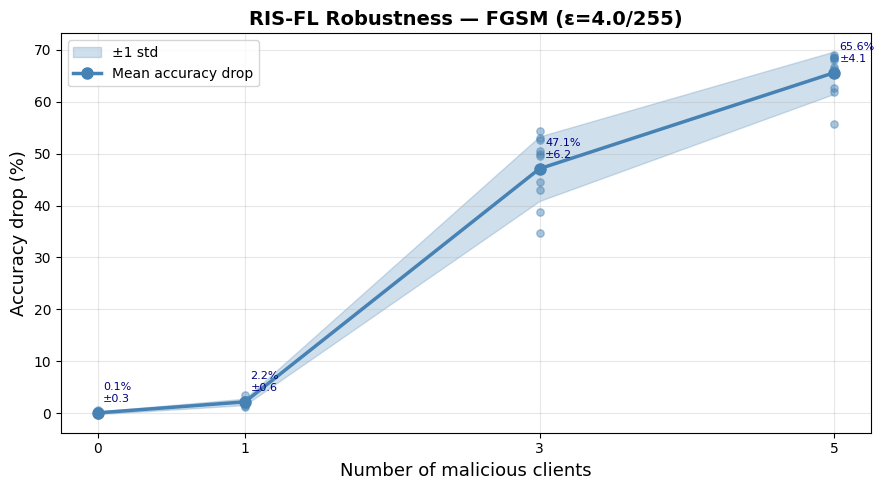

  Plot saved → results/convergence.png


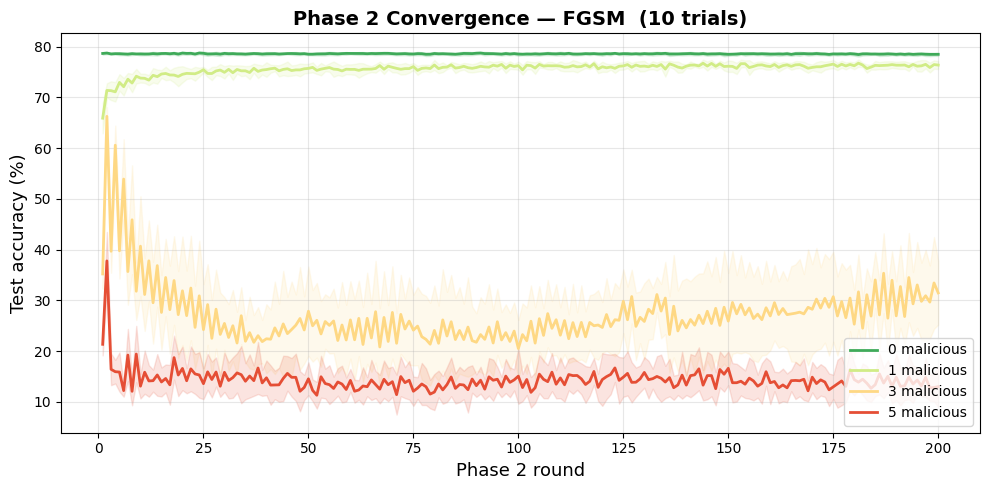


Raw results  → results/mc_results.json
Simulation log → results/simulation_logs.txt


In [16]:
# ── Terminal summary table ────────────────────────────────────────────────────
print()
print(f"{'Mal':>4} | {'P1 acc':>8} | {'P2 acc':>8} | {'Drop mean':>10} | {'Drop std':>9}")
print("─" * 55)
for n_mal in sorted(results.keys()):
    r = results[n_mal]
    print(
        f"{n_mal:>4} | "
        f"{r['p1_acc'].mean()*100:>7.2f}% | "
        f"{r['p2_acc'].mean()*100:>7.2f}% | "
        f"{r['drop_pct'].mean():>9.2f}% | "
        f"{r['drop_pct'].std():>8.2f}%"
    )

# ── Plot 1: accuracy drop ─────────────────────────────────────────────────────
plot_accuracy_drop(results, cfg, save_path='results/accuracy_drop.png')

# ── Plot 2: convergence across trials ────────────────────────────────────────
plot_convergence(results, cfg, save_path='results/convergence.png')

# ── Save raw results to JSON ─────────────────────────────────────────────────
os.makedirs('results', exist_ok=True)
serialisable = {
    str(k): {
        metric: (v.tolist() if isinstance(v, np.ndarray) else v)
        for metric, v in data.items()
    }
    for k, data in results.items()
}
with open('results/mc_results.json', 'w') as f:
    json.dump({'config': vars(cfg), 'results': serialisable}, f, indent=2, default=str)

print(f"\nRaw results  → results/mc_results.json")
print(f"Simulation log → {cfg.log_file}")